### Maximum likelihood difference scaling
Edit the numbers marked `👈` and re-run.

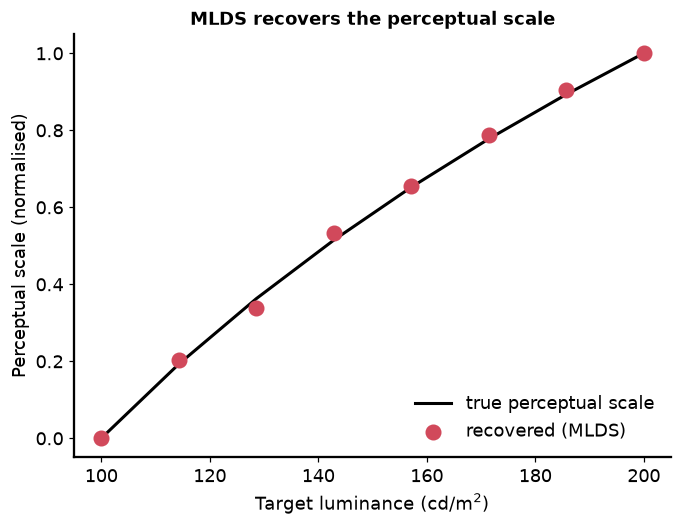

In [1]:
# (hide matplotlib's harmless one-time "building the font cache" message)
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.optimize import minimize

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 12, "axes.titlesize": 12,
    "axes.titleweight": "semibold", "axes.linewidth": 1.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False,
})
rng = np.random.default_rng()

# --- the observer's TRUE (compressive) perceptual scale over 8 stimulus levels ---
nstim  = 8
levels = np.linspace(100, 200, nstim)          # e.g. target luminance (cd/m^2)
true_scale = np.log(levels)                    # 👈 compressive perception
true_scale = (true_scale - true_scale.min()) / (true_scale.max() - true_scale.min())

noiseSD = 0.10   # 👈 perceptual noise
nreps   = 12     # 👈 repeats of each triad

# --- MLDS task: each trial shows a triad (i<j<k); is the 2nd pair more different? ---
X, y = [], []
for (i, j, k) in combinations(range(nstim), 3):
    for _ in range(nreps):
        p = true_scale[[i, j, k]] + rng.normal(0, noiseSD, 3)
        resp = abs(p[1] - p[2]) > abs(p[0] - p[1])    # 2nd pair more different?
        row = np.zeros(nstim); row[i] += 1; row[j] += -2; row[k] += 1
        X.append(row); y.append(int(resp))
X, y = np.array(X), np.array(y)

# --- recover the scale: logistic regression, no intercept, stimulus 0 fixed at 0 ---
Xfit = X[:, 1:]
def nll(b):
    p = np.clip(1 / (1 + np.exp(-(Xfit @ b))), 1e-9, 1 - 1e-9)
    return -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))
b = minimize(nll, np.zeros(nstim - 1), method="BFGS").x
recovered = np.concatenate([[0.0], b])
recovered = (recovered - recovered.min()) / (recovered.max() - recovered.min())

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(levels, true_scale, "k", lw=2, label="true perceptual scale")
ax.scatter(levels, recovered, 90, color="#d1495b", zorder=3, label="recovered (MLDS)")
ax.set(xlabel="Target luminance (cd/m$^2$)", ylabel="Perceptual scale (normalised)",
       title="MLDS recovers the perceptual scale")
ax.legend(loc="lower right")
plt.show()
